# Variability Analysis Notebook

This notebook performs the following steps:

1. **Plot Gene Expression Distribution**
2. **Compute Variability**
3. **Visualize Variability Across Datasets**

## Xenium Data (Spatial Transcriptomics)

- Raw gene counts → `scanpy.pp.normalize_total(target_sum=1e4)` → `log1p` → compute variability (CV)

## Codex Data (Spatial Proteomics)

- Z-scored protein expression → compute variability (MSE, Kurtosis, Skewness, Gini)


## 1. Import Libraries and Functions

Load required packages and helper functions for data loading, variability computation, and plotting.

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')
import matplotlib.pyplot as plt

from tic.data import load_xenium_dataset, list_regions, load_region
from tic.metrics import compute_variability
from tic.plotting import plot_variability, plot_gene_distributions_by_category
from tic.constant import EPITHELIAL_GENES, MESENCHYMAL_GENES, EMT_TF
from utils.dataset.codex_upmc import UPMC_EPITHELIAL_GENES, UPMC_MESENCHYMAL_GENES

# For nicer plots
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

## 2. Load Xenium Datasets and Compute Variability (CV)

We load three Xenium datasets (Breast, Kidney, Pancreas). Each is normalized with Scanpy (`target_sum=1e4`), log-transformed, and then we compute the Coefficient of Variation (CV) per gene.

In [2]:
# Xenium Breast
xenium_ffpe_human_breast = load_xenium_dataset(
    name='xenium_ffpe_human_breast',
    normalize='scanpy',
    log=True,
)
xenium_ffpe_human_breast_variability = compute_variability(
    xenium_ffpe_human_breast,
    dataset_type='xenium',
    metrics=['cv']
)
print("Breast CV (top 5):")
print(xenium_ffpe_human_breast_variability.head(), "\n")
# Xenium Kidney
xenium_kidney_cancer = load_xenium_dataset(
    name='xenium_kidney_cancer',
    normalize='scanpy',
    log=True,
)
xenium_kidney_cancer_variability = compute_variability(
    xenium_kidney_cancer,
    dataset_type='xenium',
    metrics=['cv']
)
print("Kidney CV (all genes):")
print(xenium_kidney_cancer_variability, "\n")
# Xenium Pancreas
xenium_pancreas_cancer = load_xenium_dataset(
    name='xenium_pancreas_cancer',
    normalize='scanpy',
    log=True,
)
xenium_pancreas_cancer_variability = compute_variability(
    xenium_pancreas_cancer,
    dataset_type='xenium',
    metrics=['cv']
)
print("Pancreas CV (all genes):")
print(xenium_pancreas_cancer_variability)


Xenium dataset 'xenium_ffpe_human_breast' already exists at /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast
2025-06-04 16:48:05,636 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_ffpe_human_breast' already exists at /Users/zhangjiahao/.cache/tic/xenium_ffpe_human_breast
2025-06-04 16:48:06,672 INFO Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-04 16:48:06,672 | INFO     | tic.data.xenium.loader | Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-04 16:48:07,175 INFO Applied log1p transformation.
2025-06-04 16:48:07,175 | INFO     | tic.data.xenium.loader | Applied log1p transformation.
2025-06-04 16:48:07,175 INFO Loaded xenium_ffpe_human_breast: 356746 cells * 541 genes.
2025-06-04 16:48:07,175 | INFO     | tic.data.xenium.loader | Loaded xenium_ffpe_human_breast: 356746 cells * 541 genes.
Xenium dataset 'xenium_kidney_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_kidney_cancer
2025-06-04 16:48:07,378 | INFO  

Breast CV (top 5):
              cv
ABCC11  2.206848
ACTA2   1.433153
ACTG2   2.160753
ADAM9   1.792467
ADGRE5  4.525798 



2025-06-04 16:48:07,588 INFO Applied log1p transformation.
2025-06-04 16:48:07,588 | INFO     | tic.data.xenium.loader | Applied log1p transformation.
2025-06-04 16:48:07,589 INFO Loaded xenium_kidney_cancer: 56510 cells * 541 genes.
2025-06-04 16:48:07,589 | INFO     | tic.data.xenium.loader | Loaded xenium_kidney_cancer: 56510 cells * 541 genes.
Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-04 16:48:07,615 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer


Kidney CV (all genes):
                    cv
ABCC11       13.704075
ACE2          7.653643
ACKR1         5.617980
ACTA2         1.479642
ACTG2         1.280869
...                ...
BLANK_0495  237.714798
BLANK_0496  137.374649
BLANK_0497   45.402321
BLANK_0498   84.092773
BLANK_0499   63.739231

[532 rows x 1 columns] 



2025-06-04 16:48:08,283 INFO Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-04 16:48:08,283 | INFO     | tic.data.xenium.loader | Normalized using `sc.pp.normalize_total(target_sum=1e4)`.
2025-06-04 16:48:08,573 INFO Applied log1p transformation.
2025-06-04 16:48:08,573 | INFO     | tic.data.xenium.loader | Applied log1p transformation.
2025-06-04 16:48:08,574 INFO Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.
2025-06-04 16:48:08,574 | INFO     | tic.data.xenium.loader | Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.


Pancreas CV (all genes):
                                 cv
ABCC11                    31.530668
ACE2                       7.253479
ACKR1                      9.149328
ACTA2                      2.412575
ACTG2                      2.690292
...                             ...
NegControlCodeword_0539  252.524078
NegControlCodeword_0540  157.617996
BLANK_0006                60.496971
BLANK_0037                59.475323
BLANK_0069                64.861961

[538 rows x 1 columns]


## 3. Define Gene Categories (Epithelial, Mesenchymal, TF)

Combine Xenium and UPMC lists to define global sets for Epithelial (E), Mesenchymal (M), and EMT Transcription Factors (TF).

In [3]:
E_GENES = set(EPITHELIAL_GENES) | set(UPMC_EPITHELIAL_GENES)
M_GENES = set(MESENCHYMAL_GENES) | set(UPMC_MESENCHYMAL_GENES)

print("Number of Epithelial genes:", len(E_GENES))
print("Number of Mesenchymal genes:", len(M_GENES))
print("EMT Transcription Factors:", EMT_TF)


Number of Epithelial genes: 4
Number of Mesenchymal genes: 7
EMT Transcription Factors: {'ZEB1', 'TWIST1', 'SNAI2', 'SNAI1', 'ZEB2'}


## 4. Plot Variability (CV) Across Xenium Datasets

We plot gene rank vs. CV for Breast, Kidney, and Pancreas datasets. Markers indicate the positions of E, M, and TF genes.

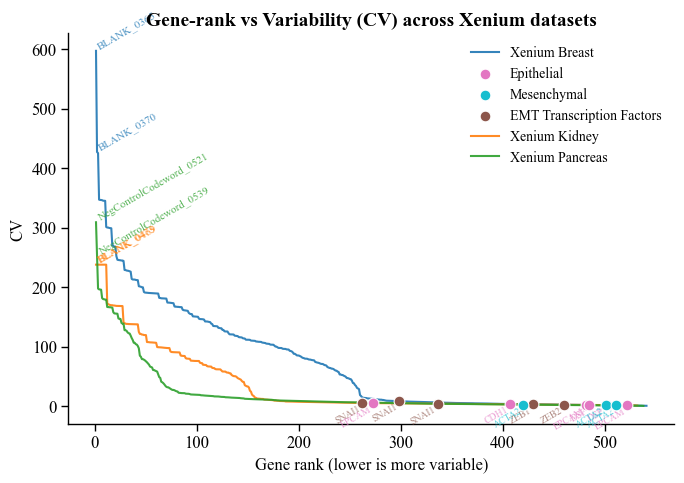

In [4]:
plot_variability(
    variability={
        "Xenium Breast": xenium_ffpe_human_breast_variability['cv'],
        "Xenium Kidney": xenium_kidney_cancer_variability['cv'],
        "Xenium Pancreas": xenium_pancreas_cancer_variability['cv'],
    },
    metric='cv',
    gene_categories={ 'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF },
    title="Gene-rank vs Variability (CV) across Xenium datasets",
    ascending=False,
    top_n=2,
    annotate_top=True,
    annotate_emt=True
)
plt.show()

## 5. Load Codex Regions and Compute Variability (MSE, Kurtosis, Skewness, Gini)

List available regions for UPMC, Charville, and DFCI. Then pick the first region from each, load it (preprocessed), and compute all four metrics.

In [5]:
# List Codex regions
upmc_regions = list_regions(dataset='upmc')
charville_regions = list_regions(dataset='charville')
dfci_regions = list_regions(dataset='dfci')

print(f"Number of regions in UPMC: {len(upmc_regions)}")
print(f"Number of regions in Charville: {len(charville_regions)}")
print(f"Number of regions in DFCI: {len(dfci_regions)}")

codex_upmc_region_1 = upmc_regions[0]
codex_charville_region_1 = charville_regions[0]
codex_dfci_region_1 = dfci_regions[0]

print(f"Codex UPMC Region 1: {codex_upmc_region_1}")
print(f"Codex Charville Region 1: {codex_charville_region_1}")
print(f"Codex DFCI Region 1: {codex_dfci_region_1}")


2025-06-04 16:48:08,854 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-04 16:48:08,854 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-06-04 16:48:12,540 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-04 16:48:12,540 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-04 16:48:12,541 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-04 16:48:12,856 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-04 16:48:12,859 INFO Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-04 16:48:12,859 | INFO     | tic.data.io | Extracting charville_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_charville


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_charville/charville_raw_data.zip


2025-06-04 16:48:14,573 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-04 16:48:14,573 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-04 16:48:14,574 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-04 16:48:14,748 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-04 16:48:14,751 INFO Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-04 16:48:14,751 | INFO     | tic.data.io | Extracting dfci_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_dfci


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_dfci/dfci_raw_data.zip


2025-06-04 16:48:15,166 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-04 16:48:15,166 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-04 16:48:15,167 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-04 16:48:15,196 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data


Number of regions in UPMC: 308
Number of regions in Charville: 292
Number of regions in DFCI: 58
Codex UPMC Region 1: UPMC_c001_v001_r001_reg001
Codex Charville Region 1: Charville_c001_v001_r001_reg001
Codex DFCI Region 1: s271_c001_v001_r001_reg001


In [6]:
# Load and compute variability for UPMC Region 1
upmc_region_1 = load_region(
    dataset='upmc',
    region_id=codex_upmc_region_1,
    preprocessed=True
)
upmc_region_1_variability = compute_variability(
    upmc_region_1,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini']
)
print("UPMC Region 1 variability (top 5):")
print(upmc_region_1_variability.head(), "\n")

# Load and compute variability for DFCI Region 1
dfci_region_1 = load_region(
    dataset='dfci',
    region_id=codex_dfci_region_1,
    preprocessed=True
)
dfci_region_1_variability = compute_variability(
    dfci_region_1,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini']
)
print("DFCI Region 1 variability (all):")
print(dfci_region_1_variability, "\n")

# Load and compute variability for Charville Region 1
charville_region_1 = load_region(
    dataset='charville',
    region_id=codex_charville_region_1,
    preprocessed=True
)
charville_region_1_variability = compute_variability(
    charville_region_1,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini']
)
print("Charville Region 1 variability (top 5):")
print(charville_region_1_variability.head())


2025-06-04 16:48:15,202 INFO Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-04 16:48:15,202 | INFO     | tic.data.io | Extracting upmc_raw_data.zip → /Users/zhangjiahao/.cache/tic/codex_upmc


Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_upmc/upmc_raw_data.zip


2025-06-04 16:48:18,784 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
2025-06-04 16:48:18,784 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_upmc
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-04 16:48:18,785 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
2025-06-04 16:48:19,058 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_upmc/raw_data
Skipping normalization and log1p because `preprocessed=True`.
2025-06-04 16:48:19,076 | INFO     | tic.data.codex.loader | Skipping normalization and log1p because `preprocessed=True`.
Loaded upmc (UPMC_c001_v001_r001_reg001): 4360 cells * 22 biomarkers.
2025-06-04 16:48:19,077 | INFO     | tic.data.codex.loader | Loaded upmc (UPMC_c001_v001_r001_reg001): 43

UPMC Region 1 variability (top 5):
            mse   kurtosis  skewness      gini
CD11b  0.986239  15.180080  3.747335  0.408389
CD14   0.986239   4.609999  2.205597  0.534604
CD15   0.986238  10.304007  3.283337  0.543754
CD163  0.986239  -0.402938  0.724250  0.456689
CD20   0.986237   8.152417  2.331158  0.376919 

Skipping download; file exists: /Users/zhangjiahao/.cache/tic/codex_dfci/dfci_raw_data.zip


2025-06-04 16:48:19,456 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
2025-06-04 16:48:19,456 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_dfci
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-04 16:48:19,456 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
2025-06-04 16:48:19,480 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_dfci/raw_data
Skipping normalization and log1p because `preprocessed=True`.
2025-06-04 16:48:19,493 | INFO     | tic.data.codex.loader | Skipping normalization and log1p because `preprocessed=True`.
Loaded dfci (s271_c001_v001_r001_reg001): 1967 cells * 41 biomarkers.
2025-06-04 16:48:19,495 | INFO     | tic.data.codex.loader | Loaded dfci (s271_c001_v001_r001_reg001): 19

DFCI Region 1 variability (all):
                    mse    kurtosis  skewness      gini
CD103          0.999490    9.158951  2.284017  0.195402
CD117          0.999491   22.851000  1.897021  0.188208
CD11b          0.999492   -0.824142  0.354307  0.433802
CD11c          0.999493   15.182938  1.294853  0.201094
CD14           0.999492    2.301630  0.796571  0.163029
CD15           0.999490    8.338881  2.846952  0.560448
CD163          0.999492    7.809579  1.901196  0.268498
CD183          0.999491    4.657442  0.834288  0.139277
CD197          0.999492  100.582260  7.825720  0.273337
CD20           0.999491    5.842716  2.163633  0.366257
CD25           0.999491    2.309544  1.238547  0.243496
CD31           0.999492   11.695113  2.077226  0.281448
CD38           0.999492    1.727797  1.032164  0.396114
CD39           0.999491   -1.019834  0.289897  0.413698
CD3e           0.999492    9.060538  3.039353  0.399844
CD4            0.999490    8.570067  2.388410  0.271121
CD45           

2025-06-04 16:48:21,201 INFO Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
2025-06-04 16:48:21,201 | INFO     | tic.data.io | Extraction complete: /Users/zhangjiahao/.cache/tic/codex_charville
Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-04 16:48:21,201 | INFO     | tic.data.codex.download | Flattening nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
2025-06-04 16:48:21,337 | INFO     | tic.data.codex.download | Removed nested directory: /Users/zhangjiahao/.cache/tic/codex_charville/raw_data
Skipping normalization and log1p because `preprocessed=True`.
2025-06-04 16:48:21,354 | INFO     | tic.data.codex.loader | Skipping normalization and log1p because `preprocessed=True`.
Loaded charville (Charville_c001_v001_r001_reg001): 2612 cells * 40 biomarkers.
2025-06-04 16:48:21,355 | INFO     | tic.data.codex.loader | Load

Charville Region 1 variability (top 5):
             mse    kurtosis   skewness      gini
CD107a  0.999617   -0.161103   0.637858  0.399577
CD117   0.999617  176.761963  11.093488  0.134816
CD11b   0.999616   18.493584   4.096679  0.418745
CD11c   0.999616   73.406944   4.436356  0.158380
CD134   0.999615  209.942398  11.874401  0.197048


## 6. Load Xenium Pancreas (Z-scored) as Codex-like Input and Compute Variability

We also demonstrate computing Codex metrics on a Xenium dataset that was z-scored (so it simulates a preprocessed space akin to Codex).

In [7]:
xenium_pancreas_cancer_zscored = load_xenium_dataset(
    name='xenium_pancreas_cancer',
    normalize='zscore',
)
xenium_pancreas_cancer_zscored_variability = compute_variability(
    xenium_pancreas_cancer_zscored,
    dataset_type='codex',
    metrics=['mse', 'kurtosis', 'skewness', 'gini']
)
print("Xenium Pancreas Z-scored variability (top 5):")
print(xenium_pancreas_cancer_zscored_variability.head())

Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-04 16:48:21,367 | INFO     | tic.data.xenium.download | Xenium dataset 'xenium_pancreas_cancer' already exists at /Users/zhangjiahao/.cache/tic/xenium_pancreas_cancer
2025-06-04 16:48:22,405 INFO Normalized using `zscore`.
2025-06-04 16:48:22,405 | INFO     | tic.data.xenium.loader | Normalized using `zscore`.
2025-06-04 16:48:22,408 INFO Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.
2025-06-04 16:48:22,408 | INFO     | tic.data.xenium.loader | Loaded xenium_pancreas_cancer: 190965 cells * 538 genes.


Xenium Pancreas Z-scored variability (top 5):
             mse     kurtosis   skewness      gini
ABCC11  1.000018  1019.514587  31.671574  0.998984
ACE2    1.000949   282.988739  14.352476  0.986567
ACKR1   0.999852   345.892029  15.623245  0.990477
ACTA2   0.998307   118.730873   8.118497  0.903720
ACTG2   0.998971    49.254238   4.494339  0.894049


## 7. Plot Variability (Kurtosis, Skewness) Across Codex & Z-scored Xenium

Compare Codex regions (UPMC, DFCI, Charville) and the Xenium pancreas z-scored dataset by plotting gene rank vs. Kurtosis and Skewness. Use log scale on the y-axis.

<Axes: title={'center': 'Gene-rank vs Skewness (Codex & Xenium Z-scored)'}, xlabel='Gene rank (lower is more variable)', ylabel='log(SKEWNESS)'>

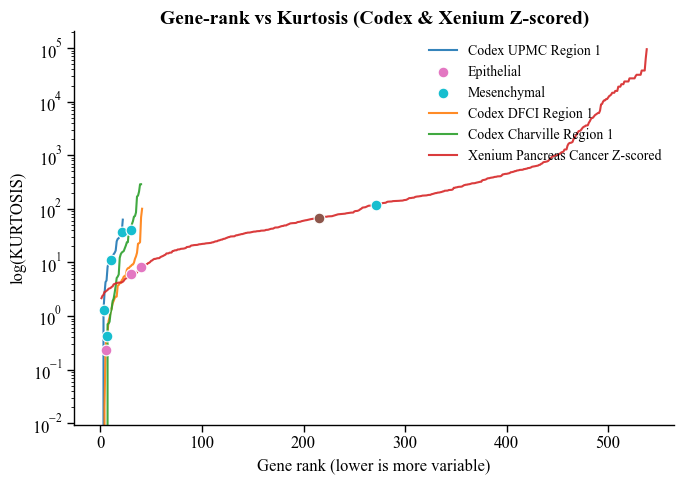

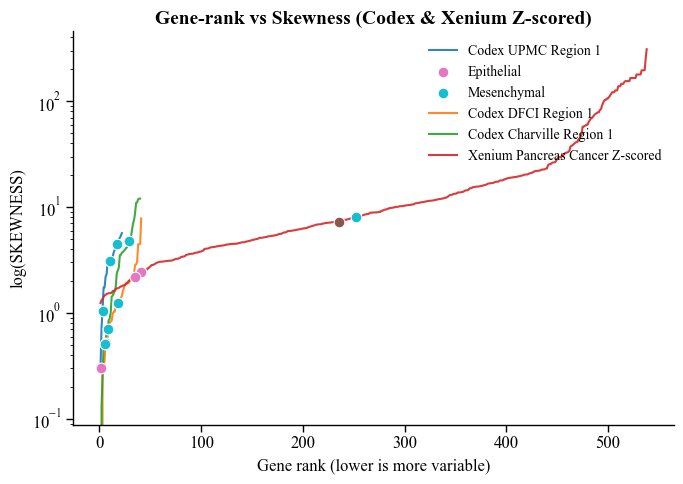

In [21]:
# Kurtosis plot
plot_variability(
    variability={
        "Codex UPMC Region 1": upmc_region_1_variability,
        "Codex DFCI Region 1": dfci_region_1_variability,
        "Codex Charville Region 1": charville_region_1_variability,
        "Xenium Pancreas Cancer Z-scored": xenium_pancreas_cancer_zscored_variability,
    },
    metric='kurtosis',
    log_y=True,
    ascending=True,
    gene_categories={'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF},
    title="Gene-rank vs Kurtosis (Codex & Xenium Z-scored)",
    top_n=2,
    annotate_top=False,
    annotate_emt=False,
)

# Skewness plot
plot_variability(
    variability={
        "Codex UPMC Region 1": upmc_region_1_variability,
        "Codex DFCI Region 1": dfci_region_1_variability,
        "Codex Charville Region 1": charville_region_1_variability,
        "Xenium Pancreas Cancer Z-scored": xenium_pancreas_cancer_zscored_variability,
    },
    metric='skewness',
    log_y=True,
    ascending=True,
    gene_categories={'Epithelial': E_GENES, 'Mesenchymal': M_GENES, 'EMT Transcription Factors': EMT_TF},
    title="Gene-rank vs Skewness (Codex & Xenium Z-scored)",
    top_n=2,
    annotate_top=False,
    annotate_emt=False,
)


## 8. Plot Gene Expression Distributions by Category

Finally, we show distribution plots of gene expression for selected categories (E, M, TF) in one Codex region and one Xenium z-scored dataset.

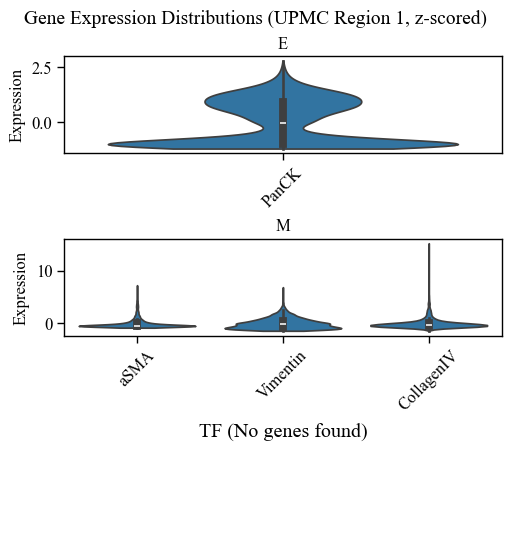

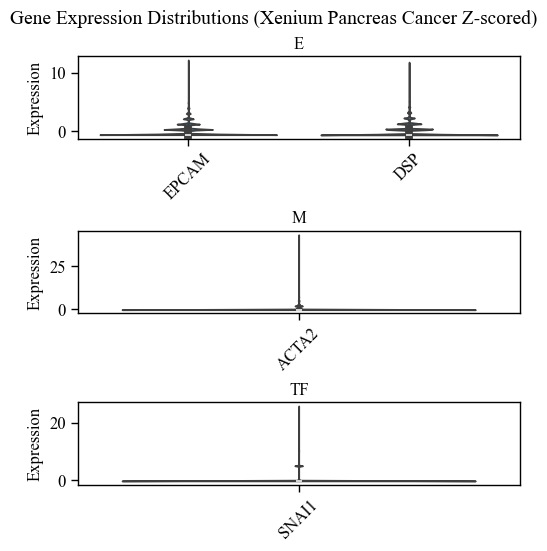

In [9]:
# UPMC Region 1 distributions (z-scored)
plot_gene_distributions_by_category(
    adata=upmc_region_1,
    gene_dict={'E': E_GENES, 'M': M_GENES, 'TF': EMT_TF},
    title="Gene Expression Distributions (UPMC Region 1, z-scored)"
)
plt.show()

# Xenium Pancreas Z-scored distributions
plot_gene_distributions_by_category(
    adata=xenium_pancreas_cancer_zscored,
    gene_dict={'E': E_GENES, 'M': M_GENES, 'TF': EMT_TF},
    title="Gene Expression Distributions (Xenium Pancreas Cancer Z-scored)"
)
plt.show()

---
**End of Notebook**